<a href="https://colab.research.google.com/github/alsavira/UTS-Machine-Learning-2304010001/blob/main/UTS_ML_Safira_Khoirulanisa_Salsabila_2304010001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UTS Machine Learning - Wine Quality Classification**

---


Nama: Safira Khoirulanisa Salsabila

NIM: 2304010001

Prodi: D3 Statistika Terapan dan Komputasi



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

In [2]:
PALETTE  = ['#264653','#2a9d8f','#e9c46a','#f4a261','#e76f51','#6d6875']
ACCENT   = '#2a9d8f'
BG       = '#f8f9fa'
plt.rcParams.update({'figure.facecolor': BG, 'axes.facecolor': BG,
                     'font.family': 'DejaVu Sans', 'font.size': 11})

def section(title):
    print("\n" + "="*65)
    print(f"  {title}")
    print("="*65)

def interp(text):
    print("\n📌 Interpretasi:")
    for line in text.strip().split('\n'):
        print(f"   {line.strip()}")

# **Persiapan Data**

In [3]:
train = pd.read_csv('/content/drive/MyDrive/Tugas Machine Learning/data_training.csv')
test = pd.read_csv('/content/drive/MyDrive/Tugas Machine Learning/data_testing.csv')

In [4]:
print(f"Data training : {train.shape[0]:,} baris × {train.shape[1]} kolom")
print(f"Data testing  : {test.shape[0]:,}  baris × {test.shape[1]} kolom")
print(f"\nKolom training : {list(train.columns)}")
print(f"Kolom testing  : {list(test.columns)}")

Data training : 857 baris × 13 kolom
Data testing  : 286  baris × 12 kolom

Kolom training : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']
Kolom testing  : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']


In [5]:
print("\n5 baris pertama data training")
print(train.head().to_string())


5 baris pertama data training
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  alcohol  quality    Id
0            7.3             0.740         0.08             1.7      0.094                 10.0                  45.0  0.99576  3.24       0.50      9.8        5  1366
1            8.1             0.575         0.22             2.1      0.077                 12.0                  65.0  0.99670  3.29       0.51      9.2        5   103
2           10.1             0.430         0.40             2.6      0.092                 13.0                  52.0  0.99834  3.22       0.64     10.0        7   942
3           12.9             0.500         0.55             2.8      0.072                  7.0                  24.0  1.00012  3.09       0.68     10.9        6   811
4            8.4             0.360         0.32             2.2      0.081                 32.0                  79.0  0.99640  3

In [6]:
print("\n5 baris pertama data testing")
print(test.head().to_string())


5 baris pertama data testing
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates    alcohol    Id
0            6.8              0.61         0.04             1.5      0.057                  5.0                  10.0  0.99525  3.42       0.60   9.500000   222
1            6.9              0.84         0.21             4.1      0.074                 16.0                  65.0  0.99842  3.53       0.72   9.233333  1514
2            7.0              0.58         0.12             1.9      0.091                 34.0                 124.0  0.99560  3.44       0.48  10.500000   417
3            7.8              0.48         0.68             1.7      0.415                 14.0                  32.0  0.99656  3.09       1.06   9.100000   754
4           12.5              0.60         0.49             4.3      0.100                  5.0                  14.0  1.00100  3.25       0.74  11.900000   516


Dataset training ini isinya fitur kimiawi anggur lengkap dengan label 'quality' dalam skala 0–10. Kolom 'quality' inilah yang berfungsi sebagai variabel target atau label untuk kita melatih modelnya.

Dataset testing memiliki struktur variabel prediktor yang identik dengan dataset training, namun tidak menyertakan kolom 'quality'. Kolom tersebut merupakan variabel dependen yang menjadi target prediksi dalam analisis ini

Langkah pertama adalah memahami struktur data sebelum masuk ke proses analisis lanjutan.


# **Data Cleaning**

## **Cek Missing Values**

In [7]:
# cek missing values pada data training

print("Missing Values – Training")
mv_train = train.isnull().sum()
print(mv_train[mv_train > 0] if mv_train.sum() > 0 else "Tidak ada missing values")
print(f"Total: {mv_train.sum()}")

Missing Values – Training
Tidak ada missing values
Total: 0


In [8]:
# cek missing values pada data testing

print("\nMissing Values – Testing")
mv_test = test.isnull().sum()
print(mv_test[mv_test > 0] if mv_test.sum() > 0 else "Tidak ada missing values")
print(f"Total: {mv_test.sum()}")


Missing Values – Testing
Tidak ada missing values
Total: 0


In [9]:
# imputasi jika ada missing values

if mv_train.sum() > 0 or mv_test.sum() > 0:
    print("\nAda missing values — imputasi dengan median...")
    train.fillna(train.median(numeric_only=True), inplace=True)
    test.fillna(test.median(numeric_only=True), inplace=True)
    print("Imputasi selesai.")

Missing values merupakan kondisi ketidaktersediaan data pada variabel tertentu dalam sebuah dataset. Apabila tidak ditangani, keberadaan data kosong ini dapat menyebabkan kegagalan pada algoritma machine learning atau menghasilkan estimasi prediksi yang bias.

Strategi penanganannya adalah dengan menerapkan imputasi median jika ditemukan data yang hilang, mengingat nilai median lebih robust (tangguh) terhadap pengaruh outlier dibandingkan nilai rata-rata (mean).

Namun, berdasarkan hasil pemeriksaan, dataset ini tidak memiliki missing values, sehingga data dapat langsung diproses ke tahap analisis selanjutnya tanpa perlu melalui prosedur imputasi.

## **Statistik Deskriptif**

In [10]:
print("\nStatistik Deskriptif Data Training")
print(train.describe().round(3).to_string())


Statistik Deskriptif Data Training
       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density       pH  sulphates  alcohol  quality        Id
count        857.000           857.000      857.000         857.000    857.000              857.000               857.000  857.000  857.000    857.000  857.000  857.000   857.000
mean           8.262             0.529        0.267           2.506      0.087               15.783                45.978    0.997    3.313      0.657   10.430    5.653   813.749
std            1.702             0.179        0.195           1.294      0.049               10.300                31.692    0.002    0.152      0.167    1.067    0.822   463.807
min            4.600             0.120        0.000           0.900      0.012                1.000                 6.000    0.990    2.740      0.390    8.400    3.000     0.000
25%            7.100             0.395        0.090           1.900  

Statistik deskriptif memperlihatkan skala nilai antar fitur sangat berbeda:

- `total sulfur dioxide` bisa mencapai ~289, sedangkan `chlorides` hanya ~0.6. Perbedaan rentang nilai antar fitur sangat kontras dan tidak seragam.

- Perbedaan skala wajib diatasi dengan Feature Scaling agar model tidak bias terhadap fitur bernilai besar.

- Nilai std yang besar pada beberapa fitur mengindikasikan adanya outlier.


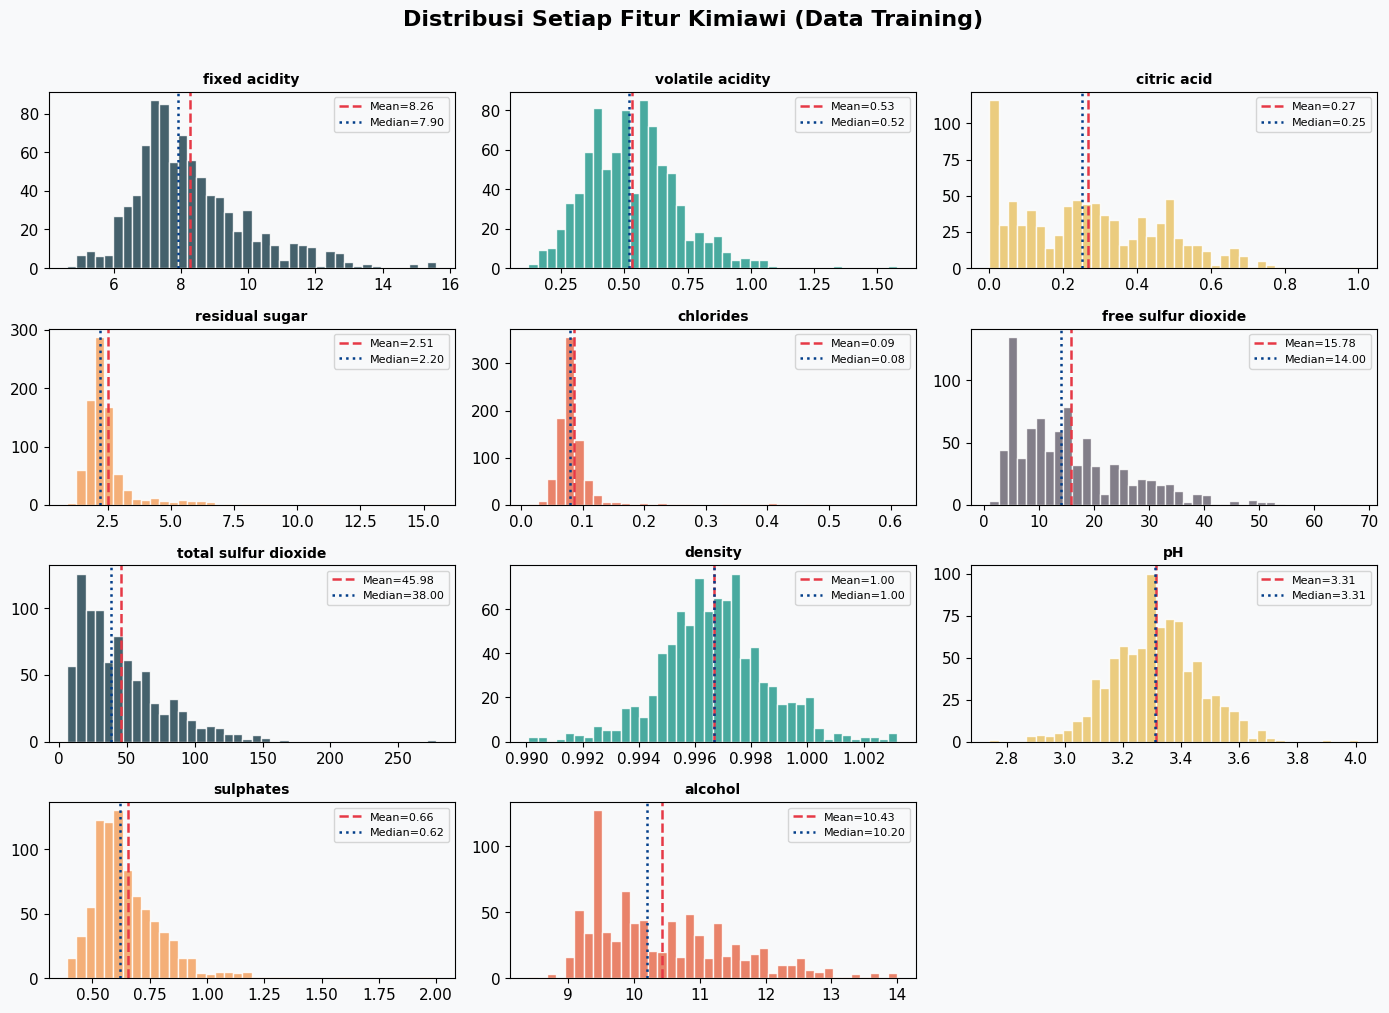

Gambar disimpan: fig1_distribusi_fitur.png


In [11]:
feature_cols = ['fixed acidity','volatile acidity','citric acid','residual sugar',
                'chlorides','free sulfur dioxide','total sulfur dioxide',
                'density','pH','sulphates','alcohol']

fig, axes = plt.subplots(4, 3, figsize=(14, 10))
fig.suptitle('Distribusi Setiap Fitur Kimiawi (Data Training)',
             fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(train[col], bins=40, color=PALETTE[i % len(PALETTE)],
                 edgecolor='white', alpha=0.85)
    axes[i].axvline(train[col].mean(),  color='#e63946', lw=1.8,
                    linestyle='--', label=f"Mean={train[col].mean():.2f}")
    axes[i].axvline(train[col].median(), color='#023e8a', lw=1.8,
                    linestyle=':',  label=f"Median={train[col].median():.2f}")
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_facecolor(BG)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gambar disimpan: fig1_distribusi_fitur.png")

Histogram tiap fitur memperlihatkan bentuk distribusi data:

- Garis merah putus-putus  = nilai mean (rata-rata)

- Garis biru titik-titik   = nilai median

- Apabila nilai rata-rata (mean) lebih besar daripada nilai tengah (median), maka dapat disimpulkan bahwa distribusi data tersebut memiliki kemiringan positif atau condong ke kanan (right-skewed), yang mengindikasikan adanya potensi data pencilan (outlier) pada rentang nilai tinggi.

- Fitur-fitur seperti `residual sugar` dan `chlorides` menunjukkan distribusi yang sangat condong ke kanan (right-skewed), yang mengindikasikan adanya pemusatan data pada nilai rendah namun memiliki ekor distribusi yang panjang ke arah nilai tinggi.

- Variabel seperti `pH` dan `density` menunjukkan pola distribusi yang mendekati normal atau simetris, di mana nilai rata-rata, median, dan modus berada pada rentang yang relatif sama.

Informasi ini penting untuk memilih strategi scaling dan imputasi yang tepat.


DISTRIBUSI TARGET (QUALITY)
quality
3      6
4     26
5    362
6    341
7    109
8     13

Total sampel: 857


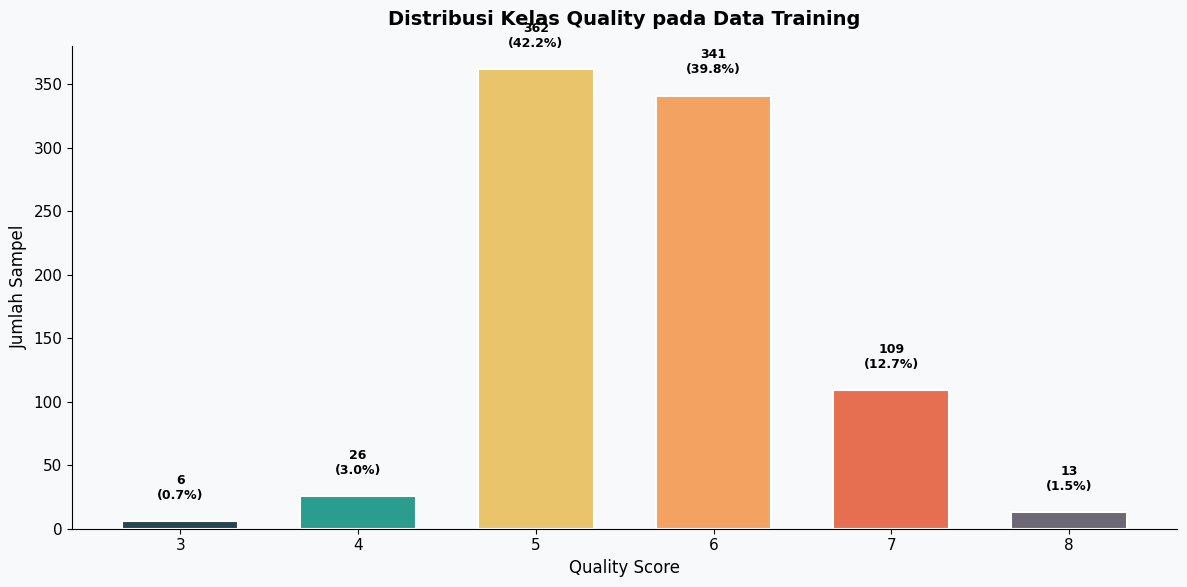

In [12]:
print(f"\033[1mDISTRIBUSI TARGET (QUALITY)\033[0m")

quality_counts = train['quality'].value_counts().sort_index()
print(quality_counts.to_string())
print(f"\nTotal sampel: {len(train):,}")

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(quality_counts.index, quality_counts.values,
              color=PALETTE[:len(quality_counts)], edgecolor='white', linewidth=1.5,
              width=0.65)

for bar, val in zip(bars, quality_counts.values):
    pct = val / len(train) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_title('Distribusi Kelas Quality pada Data Training',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quality Score', fontsize=12)
ax.set_ylabel('Jumlah Sampel', fontsize=12)
ax.set_xticks(quality_counts.index)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_distribusi_quality.png', dpi=150, bbox_inches='tight')
plt.show()

Distribusi kelas quality menunjukkan kondisi class imbalance (ketidakseimbangan kelas):

- Mayoritas: Kelas 5 dan 6 (Potensi bias prediksi tinggi).

- Minoritas: Kelas 3 dan 8 (Risiko underfitting pada kelas ekstrem).

- Karakteristik Data: Imbalanced dataset yang memengaruhi metrik evaluasi seperti F1-Score.

Solusi yang digunakan: Stratified K-Fold Cross Validation agar proporsi kelas
terjaga di setiap fold, serta model ensemble (Random Forest, Gradient Boosting)
yang lebih robust terhadap imbalance kelas dibanding model sederhana.

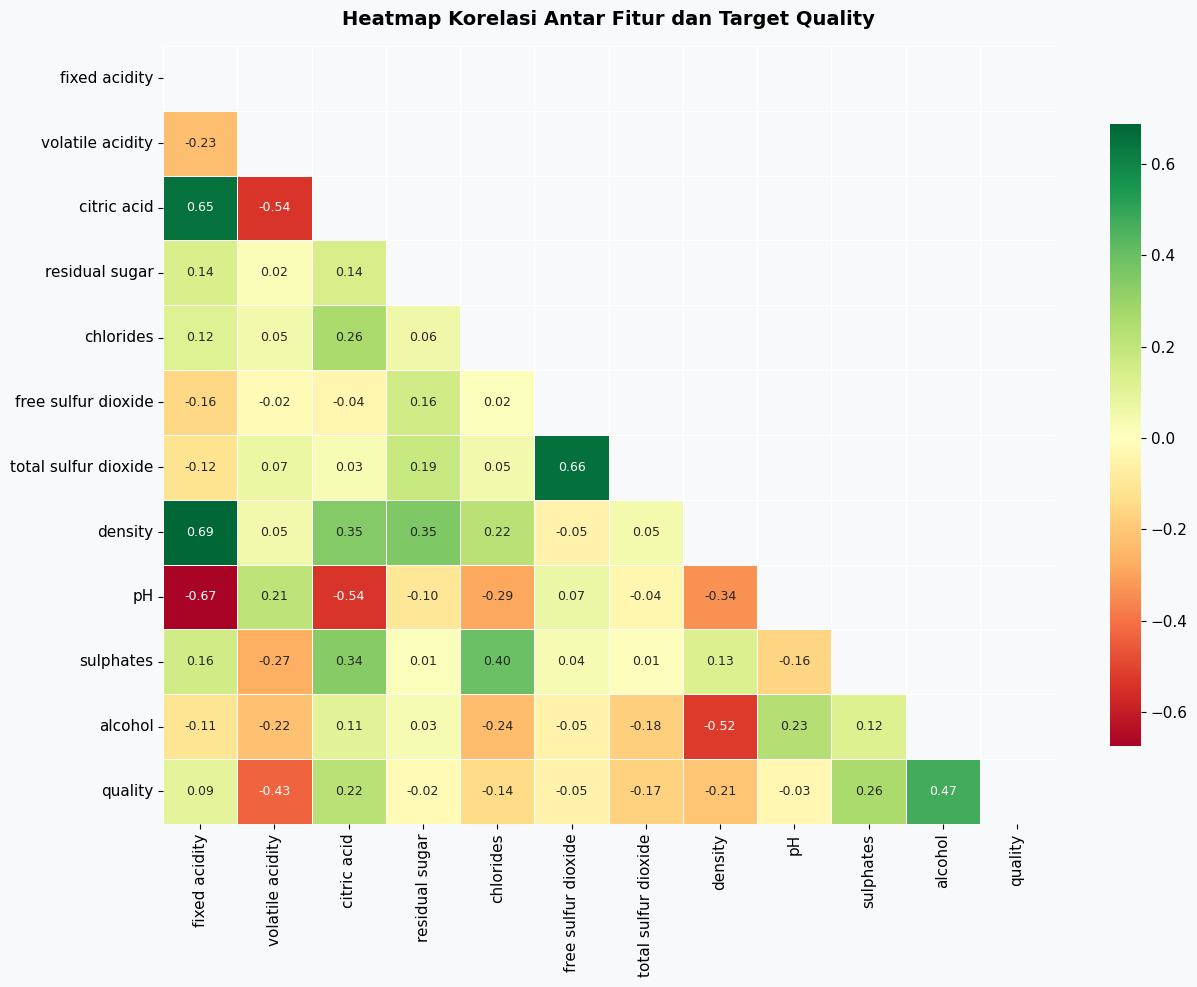

In [13]:
# heatmap correlation

fig, ax = plt.subplots(figsize=(13, 10))
corr = train[feature_cols + ['quality']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi Antar Fitur dan Target Quality',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig3_heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

Heatmap korelasi menunjukkan hubungan linear antar fitur dan target:

- Korelasi Positif (Warna HIJAU)  = Menunjukkan hubungan searah, di mana peningkatan nilai fitur diikuti oleh peningkatan skor kualitas. Contoh utamanya adalah fitur `alcohol`, yang mengindikasikan bahwa anggur dengan kadar alkohol lebih tinggi cenderung memiliki penilaian kualitas yang lebih baik.

- Korelasi Negatif (Warna Merah): Menunjukkan hubungan berbanding terbalik, di mana peningkatan nilai fitur justru menurunkan skor kualitas. Hal ini terlihat pada `volatile acidity`, di mana kandungan asam volatil yang tinggi berkorelasi dengan penurunan cita rasa dan kualitas anggur.

- Multikolinearitas: Heatmap juga mendeteksi korelasi antar variabel independen, seperti hubungan antara `density` dan `alcohol`, yang perlu diperhatikan agar tidak terjadi redundansi informasi dalam model.

Informasi korelasi membantu memahami fitur mana yang paling relevan untuk prediksi.

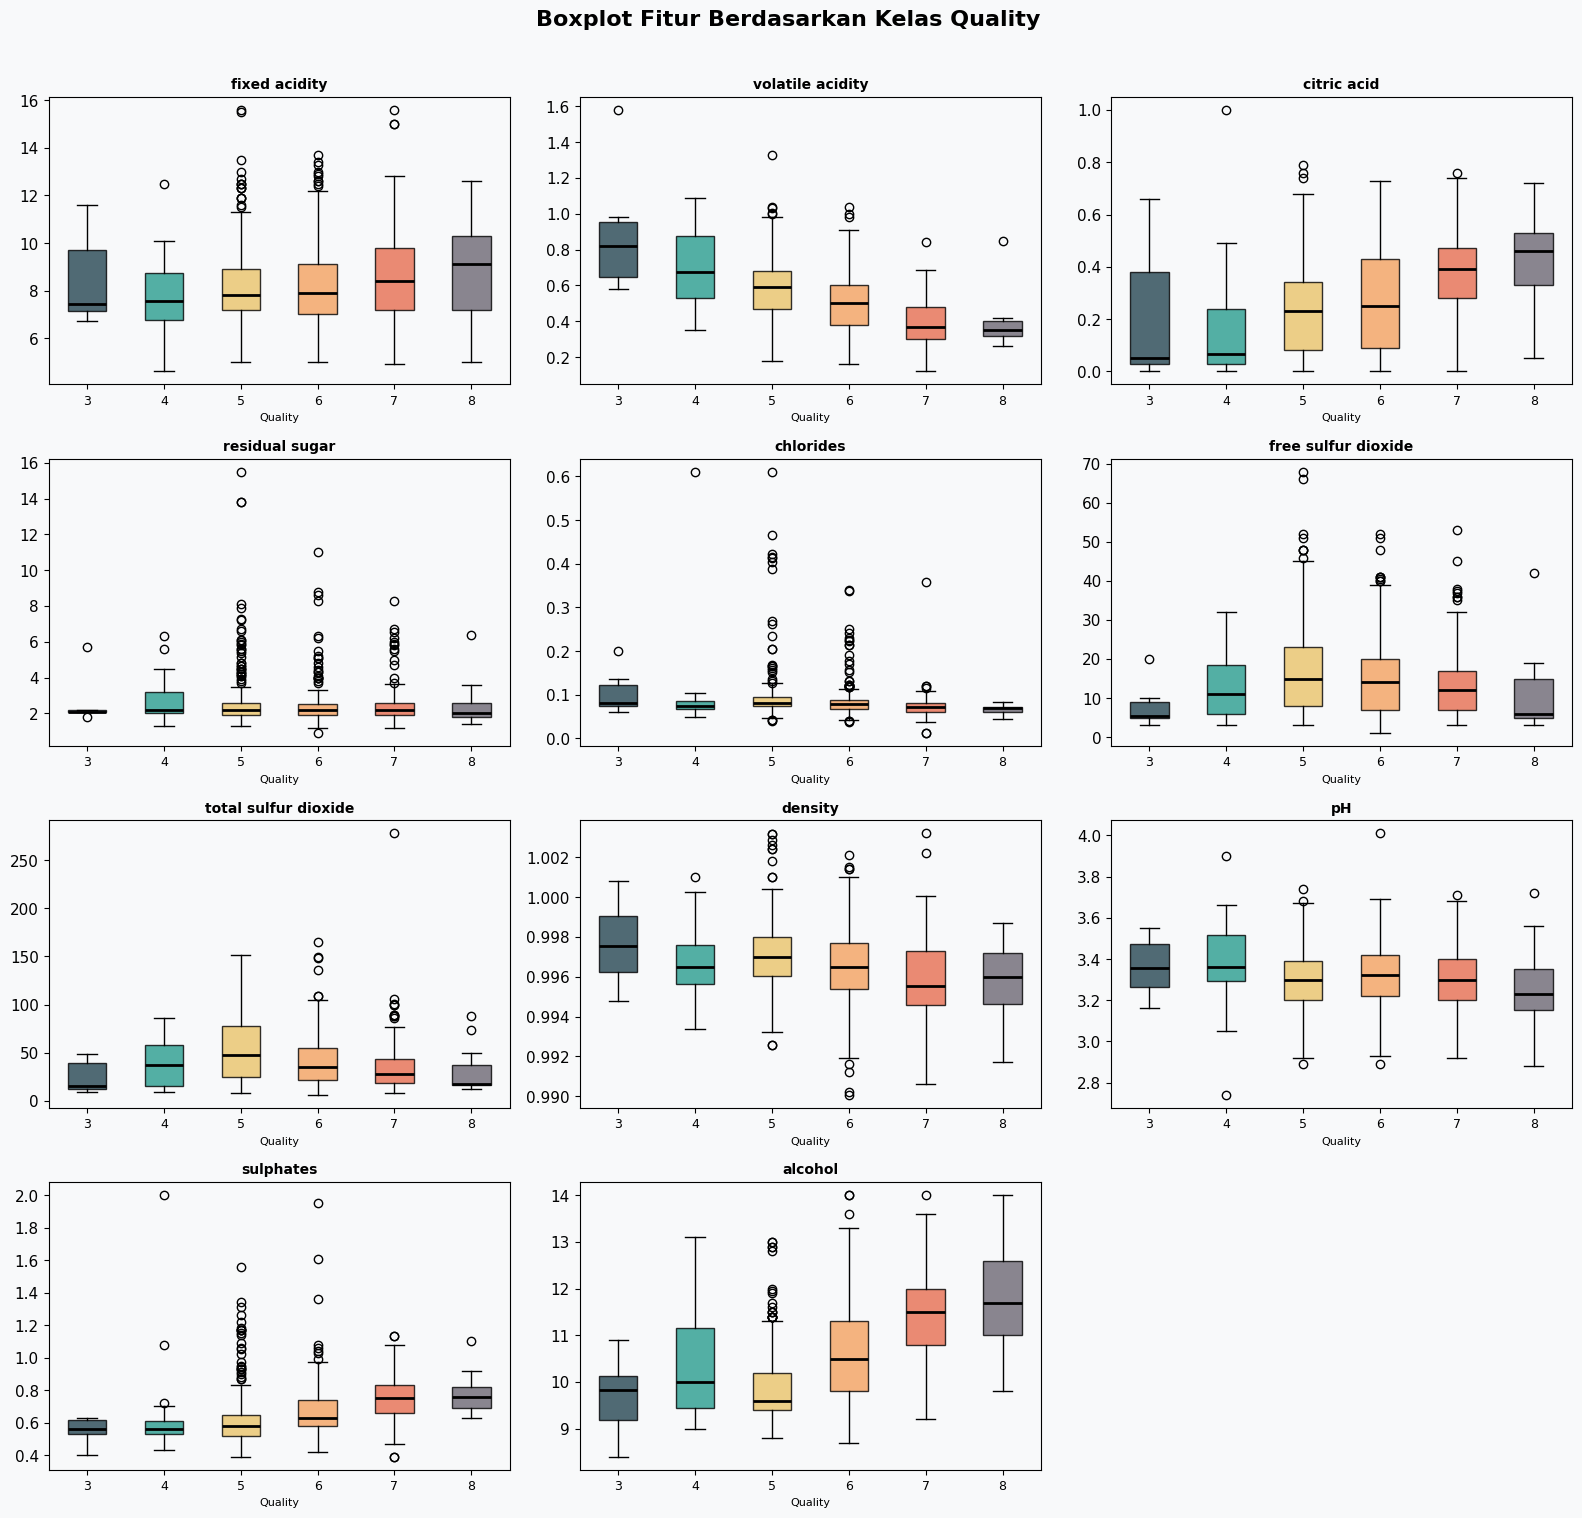

In [14]:
fig, axes = plt.subplots(4, 3, figsize=(16, 15))
fig.suptitle('Boxplot Fitur Berdasarkan Kelas Quality',
             fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    data_by_class = [train[train['quality'] == q][col].values
                     for q in sorted(train['quality'].unique())]
    bp = axes[i].boxplot(data_by_class, patch_artist=True, notch=False,
                          medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], PALETTE[:len(data_by_class)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    axes[i].set_xticklabels(sorted(train['quality'].unique()), fontsize=9)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Quality', fontsize=8)
    axes[i].set_facecolor(BG)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_boxplot_per_quality.png', dpi=150, bbox_inches='tight')
plt.show()

Visualisasi menggunakan boxplot per kelas kualitas memberikan gambaran komprehensif mengenai distribusi fitur pada setiap kategori target:
- Daya Diskriminatif: Perbedaan nilai median yang signifikan antar kelas menunjukkan bahwa fitur tersebut memiliki kemampuan diskriminatif yang kuat, sehingga sangat efektif sebagai prediktor dalam model.
- Variabilitas Data: Rentang kotak (Interquartile Range/IQR) yang sempit mencerminkan konsentrasi data yang tinggi, sedangkan kotak yang lebar menunjukkan persebaran data yang lebih bervariasi pada kelas tersebut.
- Identifikasi Outlier: Titik-titik data yang berada di luar garis batas (whisker) mengonfirmasi keberadaan outlier atau pencilan yang perlu diantisipasi.
- Kecenderungan Fitur: Fitur alcohol menunjukkan tren peningkatan median seiring dengan naiknya kualitas, sementara volatile acidity menunjukkan tren penurunan yang konsisten. Keduanya merupakan fitur krusial dengan korelasi positif dan negatif yang kuat terhadap variabel target.

# **Feature Engineering & Scaling**

In [15]:
X       = train[feature_cols]
y       = train['quality']
X_test  = test[feature_cols]

In [16]:
scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

In [17]:
# menampilkan before after scaling

before = pd.DataFrame(X, columns=feature_cols).describe().loc[['mean','std']].round(3)
after  = pd.DataFrame(X_scaled, columns=feature_cols).describe().loc[['mean','std']].round(3)

print("SEBELUM scaling (mean / std):")
print(before.to_string())
print("\nSESUDAH scaling (mean / std) — semua ~0 / ~1:")
print(after.to_string())

SEBELUM scaling (mean / std):
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density     pH  sulphates  alcohol
mean          8.262             0.529        0.267           2.506      0.087               15.783                45.978    0.997  3.313      0.657   10.430
std           1.702             0.179        0.195           1.294      0.049               10.300                31.692    0.002  0.152      0.167    1.067

SESUDAH scaling (mean / std) — semua ~0 / ~1:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density     pH  sulphates  alcohol
mean          0.000            -0.000        0.000          -0.000      0.000                0.000                -0.000    0.000  0.000     -0.000    0.000
std           1.001             1.001        1.001           1.001      1.001                1.001                 1.001    1.001  1.001  

Prosedur StandardScaler dilakukan dengan mentransformasi setiap fitur menggunakan rumus skor-z, yaitu:

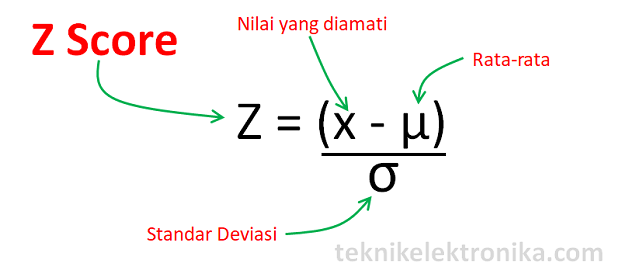

Proses ini menghasilkan distribusi data dengan rata-rata (mean) mendekati 0 dan deviasi standar (std) mendekati 1 untuk seluruh fitur.

Penerapan standarisasi ini sangat krusial karena beberapa alasan teknis berikut:
- Sensitivitas Algoritma: Algoritma yang berbasis jarak (seperti KNN atau SVM) serta berbasis gradien (seperti Regresi Logistik atau Neural Networks) sangat sensitif terhadap skala fitur.
- Pencegahan Dominasi Fitur: Tanpa scaling, fitur dengan magnitudo besar (seperti total sulfur dioxide yang bernilai ratusan) akan mendominasi perhitungan bobot model dibandingkan fitur dengan nilai kecil (seperti chlorides yang bernilai desimal), meskipun fitur kecil tersebut mungkin memiliki informasi yang lebih relevan.

Selain itu, terdapat kaidah penting dalam implementasinya: scaler wajib di-fit hanya pada data training, kemudian diaplikasikan (transform) pada data testing. Jika scaler di-fit ulang menggunakan data testing, maka akan terjadi Data Leakage, di mana model secara tidak langsung mendapatkan informasi dari data uji selama fase pelatihan, yang mengakibatkan hasil evaluasi menjadi tidak valid.

# **Pembuatan dan Evaluasi Model**

In [18]:
# Stratified K-Fold Cross Validation (5 fold)
# Stratified → proporsi kelas dipertahankan di setiap fold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
models = {
    'Random Forest (default)': RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1),
    'Random Forest (tuned)': RandomForestClassifier(
        n_estimators=500, max_depth=10, min_samples_split=5,
        min_samples_leaf=2, max_features='sqrt', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42),
}

In [20]:
cv_results = {}
print(f"{'Model':<35} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 57)
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    cv_results[name] = (model, scores.mean(), scores.std())
    print(f"{name:<35} {scores.mean():>10.4f} {scores.std():>10.4f}")

Model                                  CV Mean     CV Std
---------------------------------------------------------
Random Forest (default)                 0.6442     0.0377
Random Forest (tuned)                   0.6220     0.0281
Gradient Boosting                       0.6091     0.0208


Penerapan Stratified K-Fold Cross-Validation (5-fold) bertujuan untuk memperoleh estimasi evaluasi model yang lebih reliabel dan objektif melalui prosedur berikut:
- Mekanisme Kerja: Data dibagi menjadi 5 bagian (fold), di mana model dilatih sebanyak 5 kali. Pada setiap iterasi, satu bagian digunakan sebagai data validasi sementara empat bagian lainnya digunakan sebagai data pelatihan.
- Signifikansi 'Stratified': Teknik ini memastikan bahwa proporsi setiap kelas pada tiap fold tetap konsisten dengan distribusi pada dataset orisinal. Hal ini sangat krusial dalam menangani kondisi data yang tidak seimbang (imbalanced data).

- Metrik Evaluasi:
  - CV Mean: Rata-rata akurasi dari seluruh iterasi yang memberikan estimasi performa model saat menghadapi data baru (unseen data).
  - CV Std: Deviasi standar dari akurasi yang menunjukkan tingkat stabilitas model; nilai yang lebih kecil mengindikasikan model yang lebih konsisten.
  
Melalui perbandingan tiga model yang berbeda, kita dapat memastikan pemilihan algoritma yang paling optimal berdasarkan performa rata-rata, sehingga menghindari pemilihan model yang hanya unggul secara kebetulan pada satu skenario pembagian data tertentu.

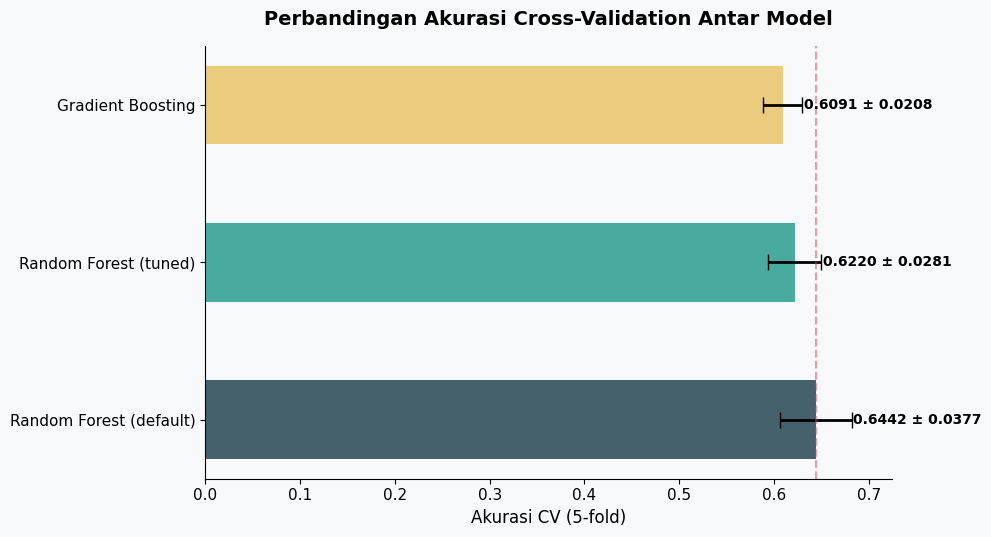

In [21]:
# visualisasi perbandungan akurasi cv

names   = list(cv_results.keys())
means   = [cv_results[n][1] for n in names]
stds    = [cv_results[n][2] for n in names]
colors  = [PALETTE[0], PALETTE[1], PALETTE[2]]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(names, means, xerr=stds, color=colors, alpha=0.85,
               height=0.5, capsize=6, error_kw={'linewidth': 2})
for bar, mean, std in zip(bars, means, stds):
    ax.text(mean + std + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f} ± {std:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Akurasi CV (5-fold)', fontsize=12)
ax.set_title('Perbandingan Akurasi Cross-Validation Antar Model',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, max(means) + 0.08)
ax.spines[['top','right']].set_visible(False)
ax.axvline(max(means), color='#e63946', linestyle='--', alpha=0.5, lw=1.5)
plt.tight_layout()
plt.savefig('fig5_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# memilih model terbaik

best_name  = max(cv_results, key=lambda k: cv_results[k][1])
best_model = cv_results[best_name][0]
best_mean  = cv_results[best_name][1]
best_std   = cv_results[best_name][2]

print(f"Model Terpilih  : {best_name}")
print(f"Akurasi CV      : {best_mean:.4f} ± {best_std:.4f}")

Model Terpilih  : Random Forest (default)
   Akurasi CV      : 0.6442 ± 0.0377


Berdasarkan hasil evaluasi, Random Forest (default) ditetapkan sebagai model terbaik karena mencatatkan nilai rata-rata akurasi Cross-Validation (CV) tertinggi. Model ini dipilih atas pertimbangan konsistensi performanya dalam menghasilkan prediksi yang akurat serta kemampuan generalisasi yang unggul terhadap data baru (unseen data).

Tahapan selanjutnya melibatkan proses pelatihan ulang (*retrain*) model menggunakan keseluruhan dataset training. Langkah ini diambil guna memastikan model mendapatkan manfaat maksimal dari seluruh informasi yang tersedia sebelum digunakan untuk melakukan prediksi pada dataset akhir.

In [23]:
# melatih ulang seluruh data training

best_model.fit(X_scaled, y)
y_train_pred = best_model.predict(X_scaled)
train_acc = accuracy_score(y, y_train_pred)

print(f"Akurasi pada data training (full fit): {train_acc:.4f}")
print(f"\nClassification Report (Data Training):\n")
print(classification_report(y, y_train_pred, zero_division=0))


Akurasi pada data training (full fit): 1.0000

Classification Report (Data Training):

              precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00       362
           6       1.00      1.00      1.00       341
           7       1.00      1.00      1.00       109
           8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



Classification Report menyajikan empat metrik evaluasi krusial untuk setiap kelas kualitas anggur:
- **Precision**: Merepresentasikan rasio prediksi benar untuk suatu kelas dibandingkan dengan total prediksi kelas tersebut. Metrik ini krusial untuk meminimalisasi kesalahan klasifikasi positif yang salah (False Positive).
- **Recall**: Mengukur kemampuan model dalam mengidentifikasi seluruh data aktual pada suatu kelas. Metrik ini sangat penting untuk memastikan tidak ada data yang terlewat dari target prediksi (False Negative).
- **F1-Score**: Merupakan rata-rata harmonik antara Precision dan Recall, yang memberikan gambaran performa model secara seimbang di antara kedua metrik tersebut.
- **Support**: Menunjukkan jumlah sampel aktual yang tersedia untuk masing-masing kelas dalam dataset.

Hasil evaluasi menunjukkan akurasi pada data training yang mencapai angka maksimal (1.00 atau 100%). Perlu dicatat bahwa nilai akurasi yang sangat tinggi pada fase full fit menggunakan algoritma Random Forest merupakan hal yang lumrah, mengingat karakteristik model ini yang mampu mempelajari data latih secara mendalam hingga berpotensi mengalami overfitting. Oleh karena itu, indikator performa yang lebih objektif tetap merujuk pada nilai akurasi Cross-Validation (CV) yang memberikan estimasi kemampuan generalisasi model terhadap data baru.

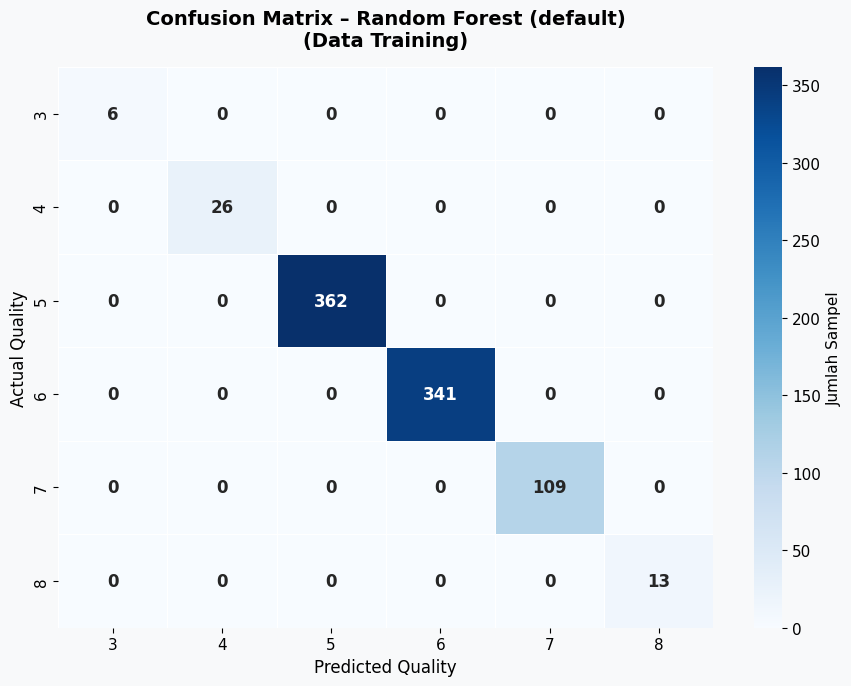

In [24]:
classes = sorted(y.unique())
cm = confusion_matrix(y, y_train_pred, labels=classes)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes,
            yticklabels=classes, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Jumlah Sampel'},
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title(f'Confusion Matrix – {best_name}\n(Data Training)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Quality', fontsize=12)
ax.set_ylabel('Actual Quality',    fontsize=12)
plt.tight_layout()
plt.savefig('fig6_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Confusion Matrix memberikan representasi visual yang mendalam mengenai kinerja prediksi model dengan rincian sebagai berikut:
- Diagonal Utama: Garis dari kiri-atas ke kanan-bawah menunjukkan jumlah prediksi yang benar. Semakin pekat warna pada sel diagonal ini, semakin tinggi tingkat akurasi model dalam mengklasifikasikan kelas tersebut.
- Elemen Luar Diagonal: Area di luar garis diagonal menunjukkan terjadinya kesalahan prediksi. Dalam hal ini, baris merepresentasikan kelas aktual (data sebenarnya), sementara kolom menunjukkan kelas hasil prediksi (estimasi model).
- Contoh Interpretasi: Angka pada pertemuan baris '5' dan kolom '6' mengindikasikan jumlah data yang secara aktual memiliki kualitas 5, namun secara keliru diprediksi oleh model sebagai kualitas 6.
- Analisis Pola: Secara umum, model cenderung melakukan kesalahan pada kelas-kelas yang saling berdekatan (seperti kualitas 5 dengan 6, atau 6 dengan 7). Hal ini lazim terjadi karena karakteristik kimiawi antar tingkatan kualitas anggur yang berdampingan sering kali memiliki batasan yang subtil dan tidak kontras secara ekstrem.

In [25]:
# feature importance

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols
                            ).sort_values(ascending=True)

    print(f"{'Fitur':<30} {'Importance':>12} {'Rank'}")
    print("-" * 55)
    for rank, (feat, imp) in enumerate(importances.sort_values(ascending=False).items(), 1):
        bar = '█' * int(imp * 100)
        print(f"{feat:<30} {imp:>12.4f}  {bar}")

Fitur                            Importance Rank
-------------------------------------------------------
alcohol                              0.1424  ██████████████
sulphates                            0.1165  ███████████
volatile acidity                     0.1122  ███████████
total sulfur dioxide                 0.0978  █████████
density                              0.0879  ████████
chlorides                            0.0816  ████████
citric acid                          0.0772  ███████
fixed acidity                        0.0753  ███████
pH                                   0.0748  ███████
residual sugar                       0.0672  ██████
free sulfur dioxide                  0.0670  ██████


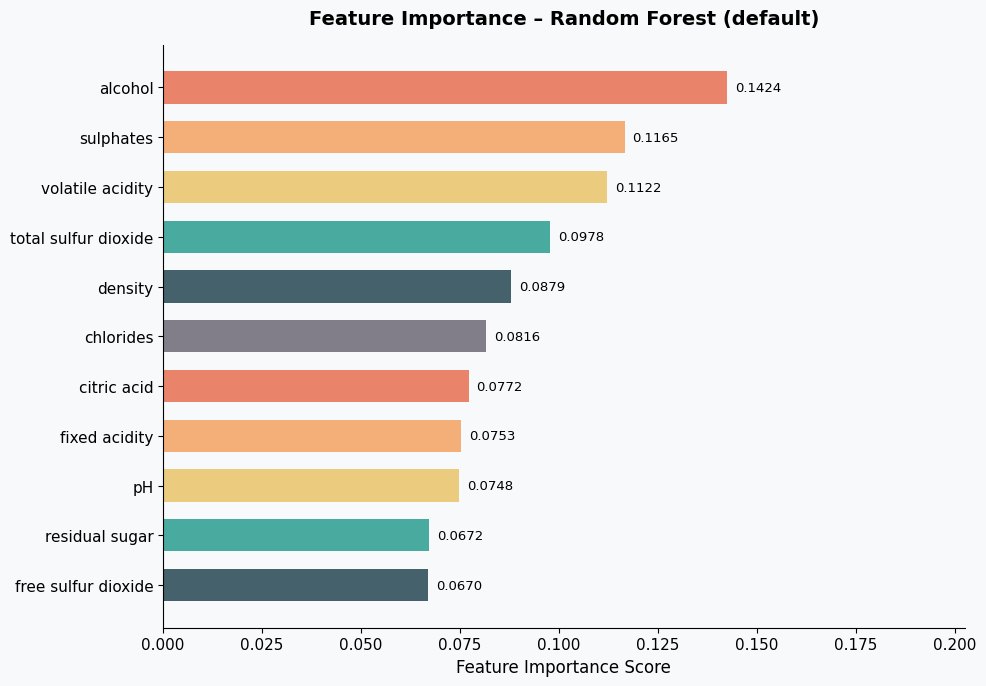

In [26]:
fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = [PALETTE[i % len(PALETTE)] for i in range(len(importances))]
bars = ax.barh(importances.index, importances.values,
               color=colors_imp, alpha=0.85, height=0.65)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9.5)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title(f'Feature Importance – {best_name}',
             fontsize=14, fontweight='bold', pad=15)
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0, importances.max() + 0.06)
plt.tight_layout()
plt.savefig('fig7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Model telah berhasil mengestimasi nilai kualitas untuk seluruh sampel dalam dataset testing. Secara keseluruhan, distribusi hasil prediksi ini menunjukkan pola yang konsisten dengan karakteristik data training yang digunakan sebelumnya

Hasil obbservasi Hasil Prediksi:
- Dominasi Kelas: Mayoritas prediksi terpusat pada kelas 5 dan 6, hal ini dinilai wajar karena selaras dengan distribusi mayoritas pada fase pelatihan.

- Representasi Kelas Ekstrem: Minimnya prediksi pada kelas minoritas (seperti kelas 3 atau 8) disebabkan oleh keterbatasan sampel data training, sehingga model belum memiliki referensi pola yang cukup kuat untuk mengidentifikasi kelas tersebut pada data baru.
- Validitas Model: Konsistensi distribusi ini menunjukkan bahwa model mampu mempertahankan pola pembelajaran yang stabil dari data latih ke data uji.

# **Prediksi Data Uji**

In [31]:
y_pred = best_model.predict(X_test_scaled)

result = pd.DataFrame({
    'Id'     : test['Id'],
    'quality': y_pred
})

print(f"Jumlah data diprediksi : {len(result):,}")
print(f"\nDistribusi hasil prediksi quality:")
dist_pred = result['quality'].value_counts().sort_index()
print(dist_pred.to_string())

print("\n10 baris pertama hasil prediksi")
print(result.head(10).to_string(index=False))

Jumlah data diprediksi : 286

Distribusi hasil prediksi quality:
quality
5    132
6    125
7     29

10 baris pertama hasil prediksi
  Id  quality
 222        5
1514        6
 417        5
 754        5
 516        5
1120        6
 180        5
  82        5
 632        6
 592        5


Model telah berhasil mengestimasi nilai kualitas untuk seluruh sampel dalam dataset testing. Secara keseluruhan, distribusi hasil prediksi ini menunjukkan pola yang konsisten dengan karakteristik data training yang digunakan sebelumnya.

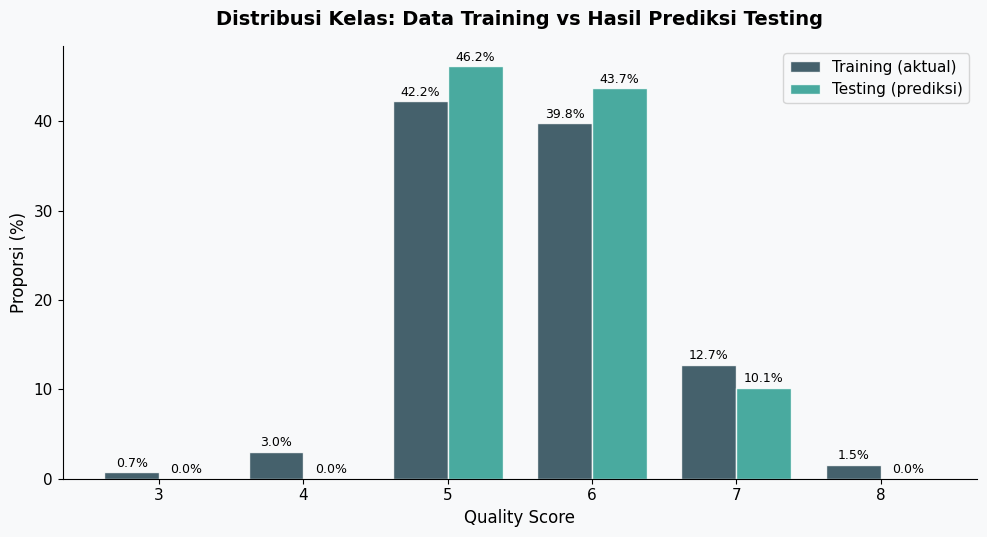

In [28]:
# visualisasi distribusi prediksi vs training

dist_train = train['quality'].value_counts().sort_index()
dist_test  = result['quality'].value_counts().sort_index()

all_classes = sorted(set(dist_train.index) | set(dist_test.index))
train_vals  = [dist_train.get(c, 0) / len(train) * 100  for c in all_classes]
test_vals   = [dist_test.get(c,  0) / len(result) * 100 for c in all_classes]

x     = np.arange(len(all_classes))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5.5))
b1 = ax.bar(x - width/2, train_vals, width, label='Training (aktual)',
            color=PALETTE[0], alpha=0.85, edgecolor='white')
b2 = ax.bar(x + width/2, test_vals,  width, label='Testing (prediksi)',
            color=PALETTE[1], alpha=0.85, edgecolor='white')

for bar, val in zip(b1, train_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
for bar, val in zip(b2, test_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Quality Score', fontsize=12)
ax.set_ylabel('Proporsi (%)',   fontsize=12)
ax.set_title('Distribusi Kelas: Data Training vs Hasil Prediksi Testing',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(all_classes)
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig8_distribusi_prediksi_vs_training.png', dpi=150, bbox_inches='tight')
plt.show()

Visualisasi perbandingan distribusi antara data training dan hasil prediksi testing berfungsi sebagai instrumen Sanity Check untuk memvalidasi konsistensi model:
- **Deteksi Anomali**: Apabila distribusi prediksi menyimpang secara signifikan dari data training, hal tersebut mengindikasikan adanya potensi galat (error) pada proses pemodelan atau transformasi data.
- **Validasi Pola**: Keserupaan pola distribusi menunjukkan bahwa model telah berhasil mengekstraksi dan menggeneralisasi karakteristik data training dengan baik ke dataset baru.
- **Toleransi Variansi**: Adanya perbedaan minor pada proporsi antar kelas dinilai wajar, mengingat data testing merupakan sampel independen dengan variabilitas yang alami.

In [29]:
# menyimpan hasil prediksi ke CSV

output_path = 'hasilprediksi_001.csv'
result.to_csv(output_path, index=False)

print(f"  File disimpan  : {output_path}")
print(f"  Jumlah baris   : {len(result):,}")
print(f"  Kolom          : {list(result.columns)}")
print(f"\nPreview file CSV:")
print(result.head(10).to_string(index=False))

  File disimpan  : hasilprediksi_001.csv
  Jumlah baris   : 286
  Kolom          : ['Id', 'quality']

Preview file CSV:
  Id  quality
 222        5
1514        6
 417        5
 754        5
 516        5
1120        6
 180        5
  82        5
 632        6
 592        5


Hasil prediksi disimpan dalam format CSV dengan HANYA 2 kolom sesuai instruksi:
- 'Id'      → identifikasi data (sesuai data_testing.csv)
- 'quality' → hasil prediksi kualitas anggur (skala 3–8)
File siap dikumpulkan dengan nama 'hasilprediksi_001.csv'.